# Exploratory Data Analysis

In [2]:
# Imports
import os
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter
from scripts.preprocess import *
from scripts.models import *

sns.set(style="whitegrid")

Load the three CSVs and merge them. These are our ground truth data files.

In [3]:
DATA_DIR = "../finalproject_data/batch_1"
output_filepath = "../finalproject_data/cleaned_invoices.csv"

# Use preprocessing CSV fnunction
df = preprocess_csv_files(DATA_DIR,output_path=output_filepath)

print("Shape:", df.shape)
df.head()

Shape: (1413, 11)


,File Name,OCRed Text,batch_csv,client_name,seller_name,invoice_number,invoice_date,due_date,tax,total_amount,net_worth
0,batch1-0494.jpg,Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,Clark-Foster,Nguyen-Roach,84652373,2021-02-23,NaT,21.18,232.95,211.77
1,batch1-0489.jpg,Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"Williams, Schneider and Gomez",Scott-Howard,37451664,2020-06-11,NaT,13.99,153.92,139.93
2,batch1-0499.jpg,Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,Hester Inc,"Bailey, Murray and Lewis",40108666,2020-02-07,NaT,45.29,498.21,452.92
3,batch1-0497.jpg,Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"Olson, Cisneros and Moore","Merritt, Williams and Young",73285932,2017-07-25,NaT,61.59,677.47,615.88
4,batch1-0081.jpg,Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,Wilson-Wilson,Fernandez Ltd,15288019,2014-09-07,NaT,0.16,1.71,1.55


## Invoice Image Examples

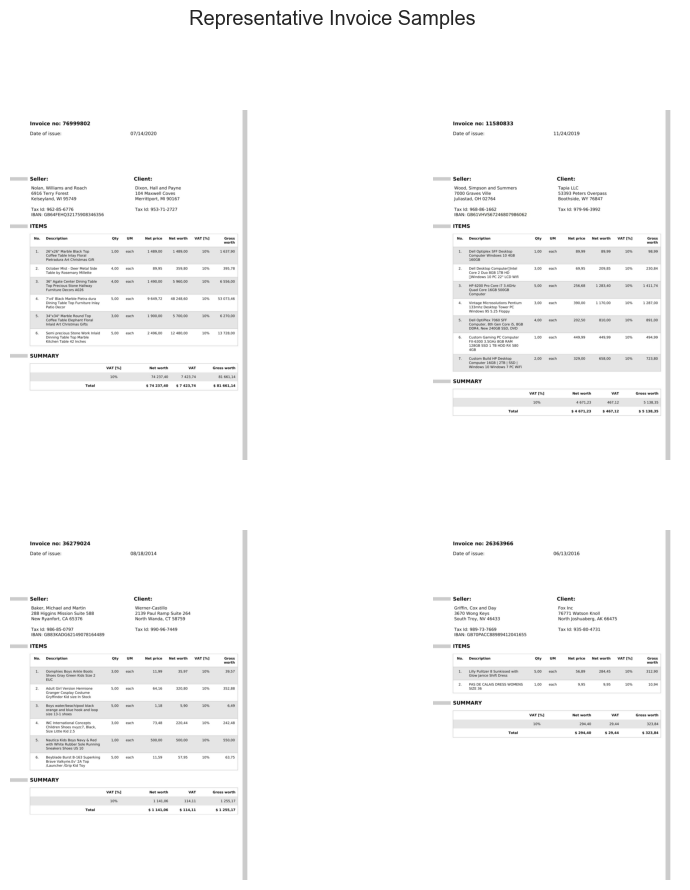

In [4]:
image_sample = df.sample(4)

fig, axes = plt.subplots(2,2, figsize=(10,10))

for ax, (_, row) in zip(axes.flatten(), image_sample.iterrows()):

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR  + "/" + folder + "/" + row["File Name"]

    img = Image.open(img_path)

    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Representative Invoice Samples")
plt.show()

# OCR Text Examples

Let's take a look at the text that we should be expecting our models to extract.

In [5]:
ocr_text_sample = df.sample(5)

for _, row in ocr_text_sample.iterrows():

    print("Invoice number:", row["invoice_number"])
    print("OCR snippet:", row["OCRed Text"][:200])
    print()

Invoice number: 90292361
OCR snippet: Invoice no: 90292361 Date of issue: 05/21/2019 Seller: Client: Lewis-Gardner Barnett PLC 5339 Tracie Haven Apt: 666 9469 Jeffrey Ports Watkinsfurt; NC 22820 Wernerside, CO 83109 Tax Id: 962-72-2326 Ta

Invoice number: 45562249
OCR snippet: Invoice no: 45562249 Date of issue: 10/19/2018 Seller: Client: Mccormick PLC Williams, Smith and Myers 5000 Ramos Square 839 Mason Squares Apt: 624 Normaberg, GA 40612 North Brian; NH 59718 Tax Id: 95

Invoice number: 17345626
OCR snippet: Invoice no: 17345626 Date of issue: 09/26/2012 Seller: Client: Stewart; Howard and Williams Hunt Group 7134 Gina Trail 95724 Judy Falls Fosterbury, MN 12314 New Marytown, Ml 99424 Tax Id: 983-88-6316 

Invoice number: 95635623
OCR snippet: Invoice no: 95635623 Date of issue: 08/11/2019 Seller: Client: Jones, English and Perry Diaz Ltd 74041 Brian Camp Suite 502 166 David Mission East James, SC 21896 Lake Seanview, NY 94455 Tax Id: 916-8

Invoice number: 64994538
OCR snippet: In

## Missingness analysis

Explore which of the extracted fields have missing fields and how many.

In [6]:
target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "due_date",
    "tax",
    "total_amount"
]

missing_table = df[target_fields].isna().sum().sort_values(ascending=False)

print(missing_table)

due_date          1413
client_name          0
seller_name          0
invoice_number       0
invoice_date         0
tax                  0
total_amount         0
dtype: int64


Only one fields has missing values: *due_date*. Since *due_date* does not contain any values across all records, we will drop it.

In [7]:
df.drop(columns=["due_date"], inplace=True)

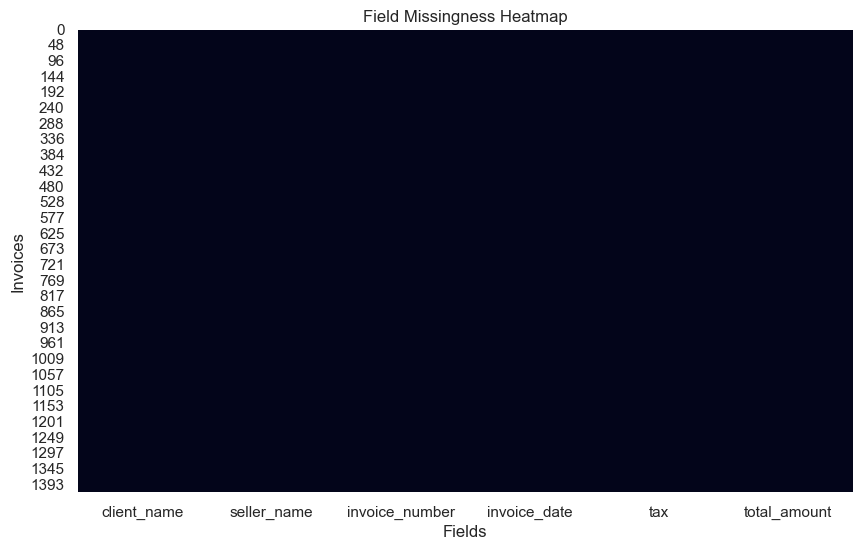

In [8]:
new_target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "tax",
    "total_amount"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[new_target_fields].isna(), cbar=False)
plt.title("Field Missingness Heatmap")
plt.xlabel("Fields")
plt.ylabel("Invoices")
plt.show()

## Vendor distribution
Find how many vendors exist and how many invoices per vendor. 

There are 1361 unique vendors with the top occurring vendors only having 2 or 3 invoices. This may present a large variability in the types of products sold. 

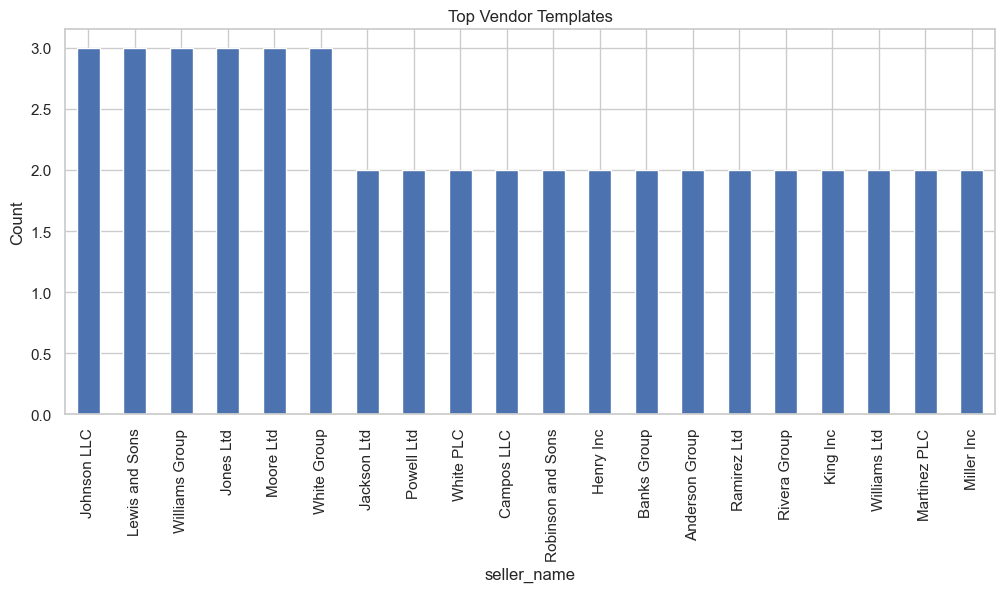

Unique vendors: 1361


In [9]:
vendor_counts = df["seller_name"].value_counts()

plt.figure(figsize=(12,5))
vendor_counts.head(20).plot(kind="bar")
plt.title("Top Vendor Templates")
plt.ylabel("Count")
plt.show()

print("Unique vendors:", df["seller_name"].nunique())

In [10]:
vendor_counts = df["seller_name"].value_counts()
print(vendor_counts)

seller_name
Johnson LLC                     3
Lewis and Sons                  3
Williams Group                  3
Jones Ltd                       3
Moore Ltd                       3
                               ..
Navarro Inc                     1
Mitchell, Acevedo and Wright    1
Thomas, Gonzalez and Bennett    1
Smith, Campbell and Gonzales    1
Burns, Figueroa and Hawkins     1
Name: count, Length: 1361, dtype: int64


## Currency detection
Find the currencies used in the invoices. It turns out they are all in US Dollars.

In [11]:
currency_symbols = ["$", "€", "£", "¥", "₹"]

def detect_currency(text):
    if pd.isna(text):
        return None
    for sym in currency_symbols:
        if sym in text:
            return sym
    return "unknown"

df["currency"] = df["OCRed Text"].apply(detect_currency)

df["currency"].value_counts()

currency
$    1413
Name: count, dtype: int64

## Image resolution & aspect ratio

It seems that the image sizes and aspect ratios are consistent across all image files in the data. 

In [12]:
image_sizes = []
aspect_ratios = []

for i, row in df.iterrows():

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR + "/" + folder + "/" + row["File Name"]

    try:
        img = Image.open(img_path)
        w, h = img.size

        image_sizes.append((w,h))
        aspect_ratios.append(w/h)

    except:
        image_sizes.append((None,None))
        aspect_ratios.append(None)

df["width"] = [x[0] for x in image_sizes]
print(df["width"].value_counts())
df["height"] = [x[1] for x in image_sizes]
print(df["height"].value_counts())

df["aspect_ratio"] = aspect_ratios
print(df["aspect_ratio"].value_counts())

width
1654    1413
Name: count, dtype: int64
height
2339    1413
Name: count, dtype: int64
aspect_ratio
0.70714    1413
Name: count, dtype: int64


## OCR token counts
Measure document complexity. We see that the distribution of token count across all documents is relatively normal. However, there is a large number of invoices with 82-84 tokens per document.

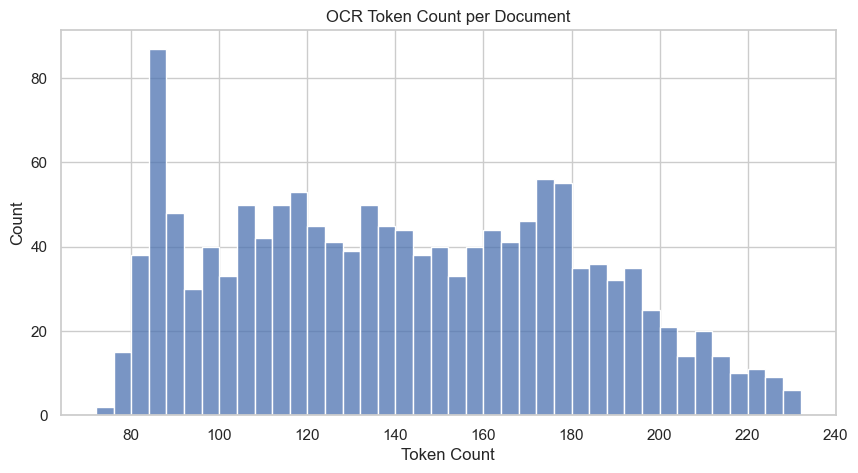

In [13]:
# Count tokens per invoice
df["ocr_tokens"] = df["OCRed Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df["ocr_tokens"], bins=40)
plt.title("OCR Token Count per Document")
plt.xlabel("Token Count")
plt.show()

## Word Cloud
Common invoice vocabulary is shown in the word cloud below. The most common words are ones that represent the standard fields like Net worth, Tax, ID, VAT, etc.

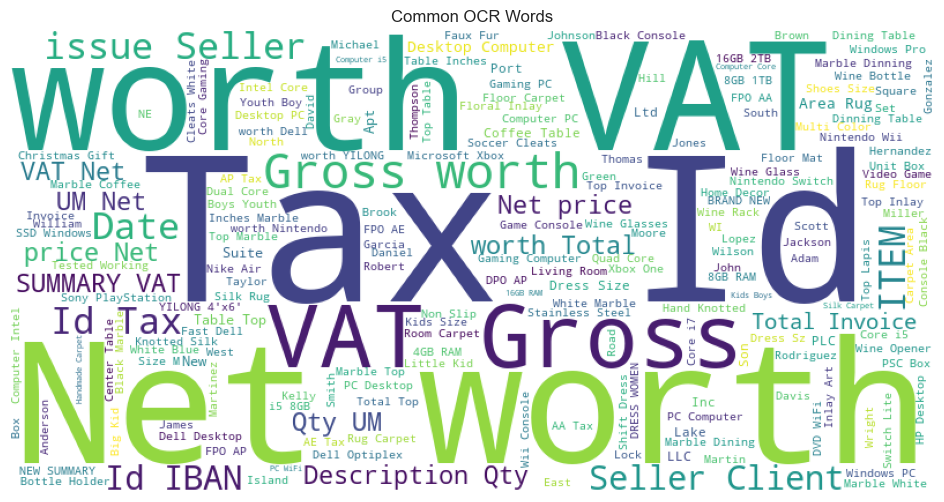

In [14]:
all_text = " ".join(df["OCRed Text"].astype(str))

wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Common OCR Words")
plt.show()

## Invoice number statistics

Check to see if the invoice number structure is standardized. We see that all of the invoice numbers are 8 characters long.

In [15]:
df["invoice_number_length"] = df["invoice_number"].astype(str).apply(len)
print(df["invoice_number_length"].value_counts())

invoice_number_length
8    1413
Name: count, dtype: int64


## Total amount, net_worth, and tax analysis

Plotting a histogram for the total amounts show us the values are heavily skewed right.

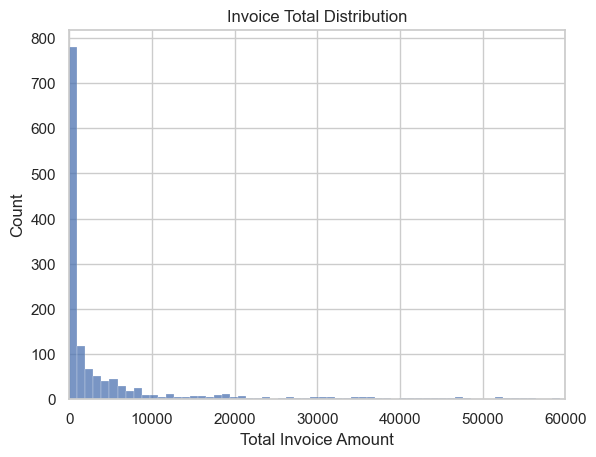

In [16]:
sns.histplot(df["total_amount"].dropna(), bins=200)
plt.xlim(0, 60000)
plt.title("Invoice Total Distribution")
plt.xlabel("Total Invoice Amount")
plt.show()

Identify the summary statistics for the invoice totals.

In [17]:
print("Summary Statistics of Total Amount:")
df["total_amount"].describe()

Summary Statistics of Total Amount:


count      1413.000000
mean       7844.664614
std       19257.110892
min           1.090000
25%         210.800000
50%         692.780000
75%        5013.800000
max      194521.700000
Name: total_amount, dtype: float64

In [18]:
print("Number of values:", len(df["total_amount"]))
print("Number of unique values: ", df['total_amount'].nunique())
print("Number of missing values: ", df['total_amount'].isna().sum())

Number of values: 1413
Number of unique values:  1374
Number of missing values:  0


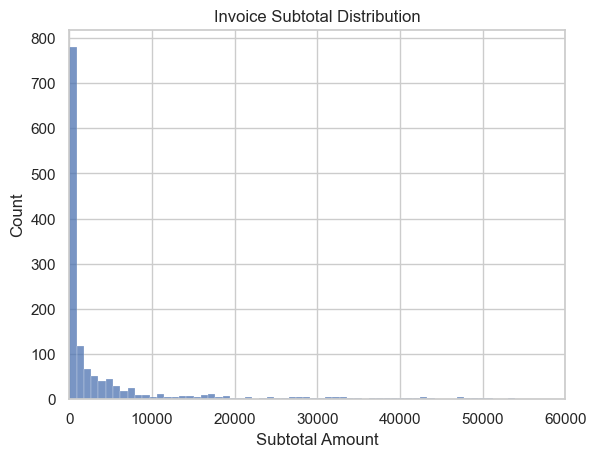

In [19]:
sns.histplot(df["net_worth"].dropna(), bins=200)
plt.xlim(0, 60000)
plt.title("Invoice Subtotal Distribution")
plt.xlabel("Subtotal Amount")
plt.show()

Identify the summary statistics for the invoice subtotals.

In [20]:
print("Summary Statistics of Subtotal:")
df["net_worth"].describe()

Summary Statistics of Subtotal:


count      1413.000000
mean       7131.276016
std       17506.497256
min           0.990000
25%         191.640000
50%         629.800000
75%        4558.000000
max      176837.910000
Name: net_worth, dtype: float64

In [21]:
print("Number of values:", len(df["net_worth"]))
print("Number of unique values: ", df['net_worth'].nunique())
print("Number of missing values: ", df['net_worth'].isna().sum())

Number of values: 1413
Number of unique values:  1373
Number of missing values:  0


Identify the summary statistics for the invoice tax.

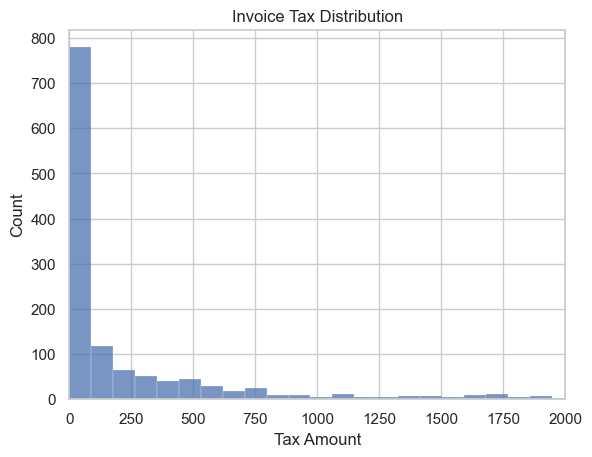

In [22]:
sns.histplot(df["tax"].dropna(), bins=200)
plt.xlim(0, 2000)
plt.title("Invoice Tax Distribution")
plt.xlabel("Tax Amount")
plt.show()

In [23]:
print("Summary Statistics of Invoice Tax:")
df["tax"].describe()

Summary Statistics of Invoice Tax:


count     1413.000000
mean       713.388594
std       1750.617141
min          0.100000
25%         19.160000
50%         62.980000
75%        455.800000
max      17683.790000
Name: tax, dtype: float64

In [24]:
print("Number of values:", len(df["tax"]))
print("Number of unique values: ", df['tax'].nunique())
print("Number of missing values: ", df['tax'].isna().sum())

Number of values: 1413
Number of unique values:  1300
Number of missing values:  0


## Initial baseline model


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [01:04<00:00,  6.48s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:55<00:00,  6.13s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [01:05<00:00,  6.53s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


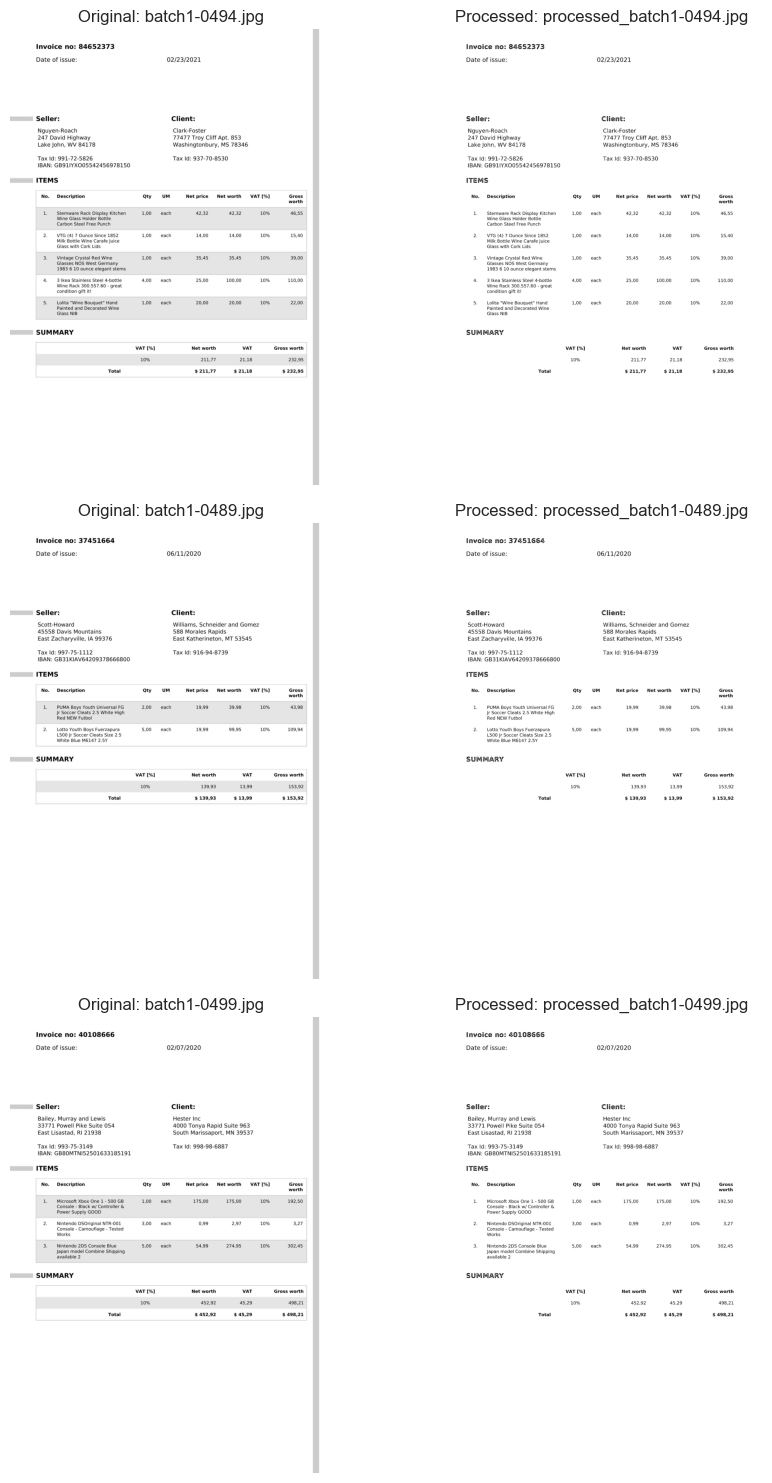

Processed images saved to: ../finalproject_data/processed_images


In [25]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [ ]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
# Merge DFs to get processed image file paths
ground_truth_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
print(ground_truth_df.columns)
ground_truth_df.drop(columns=["File Name", "due_date"], inplace=True)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth', 'original_file', 'processed_file', 'original_path',
       'processed_path', 'status'],
      dtype='str')


In [27]:
# Initialize text detector
text_detector = InvoiceTextDetector(output_dir="../finalproject_data/output_images")

summary_df = text_detector.process_dataset(combined_results, sample_frac=0.1)

Processing 141 sampled images (10.0%)...


Processing OCR batches: 100%|██████████| 15/15 [02:02<00:00,  8.15s/it]


TEXT DETECTION SUMMARY
Total images processed: 141
Successful extractions: 141
Failed extractions: 0
Average words per image: 139.3
Average confidence: 93.8%

Extracted invoice fields:
  invoice_number: 141 images (100.0%)
  invoice_date: 141 images (100.0%)
  seller_name: 141 images (100.0%)
  client_name: 141 images (100.0%)
  tax: 120 images (85.1%)
  net_worth: 114 images (80.9%)
  total_amount: 120 images (85.1%)


In [28]:
metrics_df, overall = text_detector.evaluate_against_ground_truth(ground_truth_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1414
Ground truth unique keys: 1413
Key overlap: 141
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 141              141      141  1.000000   
1    invoice_date                 141              141      141  1.000000   
2     seller_name                 141              141      141  1.000000   
3     client_name                 141              141      141  1.000000   
4       net_worth                 141              114      109  0.773050   
5    total_amount                 141              120      112  0.794326   
6             tax                 141              120      118  0.836879   

   precision    recall        f1  
0   1.000000  1.000000  1.000000  
1   1.000000  1.000000  1.000000  
2   1.000000  1.000000  1.000000  
3   1.000000  1.000000  1.000000  
4   0.956140  0.773050  0.854902  
5   0.933333  0.794326  0.858238  
6   0.983333  0.8